In [1]:
# Slide 8
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import Counter

8.1 – Huffman Coding (Encoding & Decoding)

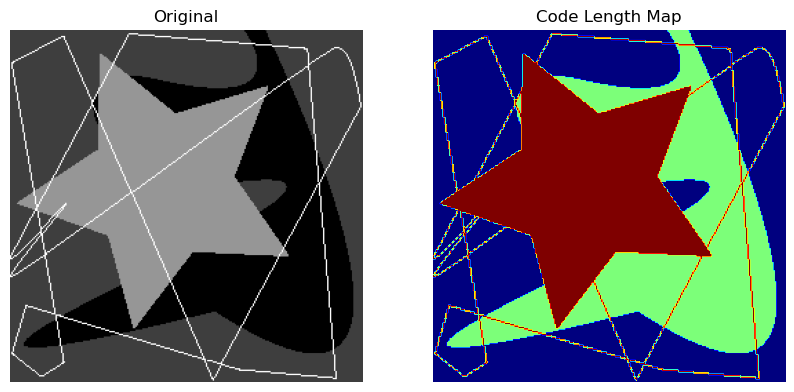

In [2]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def huffman_encoding(data):
    hist = Counter(data.flatten())
    heap = [[weight, [symbol, ""]] for symbol, weight in hist.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)
        for pair in lo[1:]: pair[1] = '0' + pair[1]
        for pair in hi[1:]: pair[1] = '1' + pair[1]
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])
    return dict(sorted(heapq.heappop(heap)[1:], key=lambda p: (len(p[-1]), p)))

huff_dict = huffman_encoding(img)
encoded_len = sum(Counter(img.flatten())[k] * len(v) for k, v in huff_dict.items())
# Simplified visual representation: showing the frequency-based map
huff_map = np.zeros_like(img, dtype=np.float32)
for i in range(256): huff_map[img == i] = len(huff_dict.get(i, ""))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(huff_map, cmap='jet'); plt.title('Code Length Map'); plt.axis('off')
plt.show()

8.2 – Run-Length Encoding (RLE)

[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.978] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

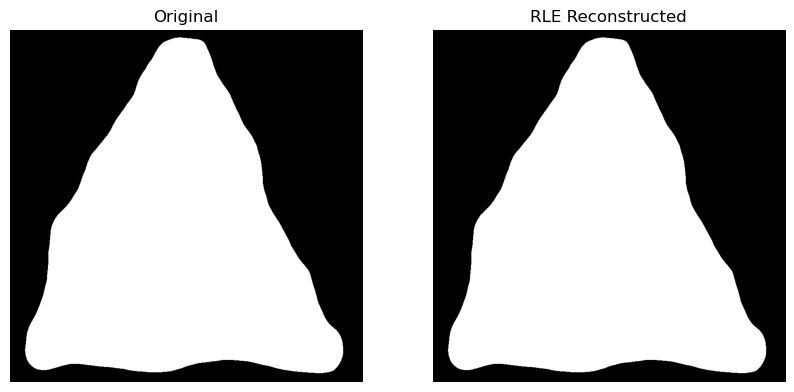

In [3]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1111(a)(triangle).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def rle_encode(flat_data):
    encoding = []
    if len(flat_data) == 0: return encoding
    prev = flat_data[0]
    count = 0
    for pixel in flat_data:
        if pixel == prev: count += 1
        else:
            encoding.append((prev, count))
            prev = pixel
            count = 1
    encoding.append((prev, count))
    return encoding

flat = img.flatten()
encoded = rle_encode(flat)
# Reconstruction for display
decoded = np.array([val for val, count in encoded for _ in range(count)]).reshape(img.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(decoded, cmap='gray'); plt.title('RLE Reconstructed'); plt.axis('off')
plt.show()

8.3 – Lossless Predictive Coding

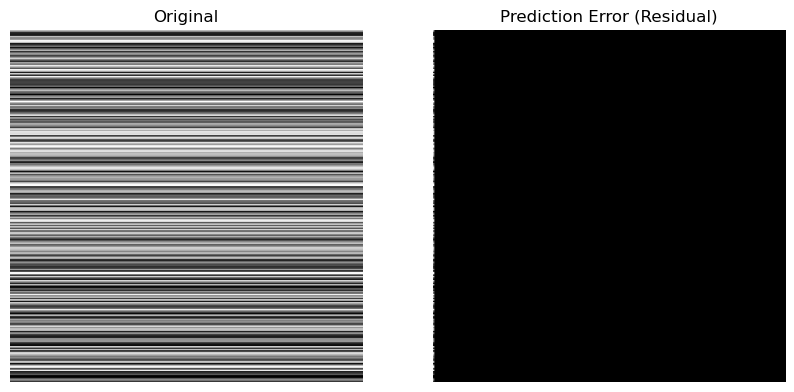

In [4]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(b).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.int16)

# Simple 1D predictor: f_hat(x,y) = f(x, y-1)
diff = np.zeros_like(img)
diff[:, 1:] = img[:, 1:] - img[:, :-1]
diff[:, 0] = img[:, 0]

# Mapping differences to positive values for visualization
vis_diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(vis_diff, cmap='gray'); plt.title('Prediction Error (Residual)'); plt.axis('off')
plt.show()

8.4 – Bit Plane Slicing (Bit Plane Coding)

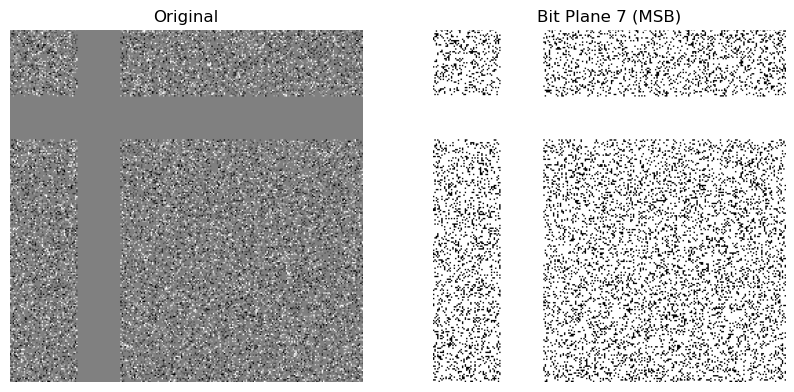

In [5]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(c).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Extracting 8th bit plane (MSB)
bit_plane_7 = (img >> 7) & 1
bit_plane_7 = (bit_plane_7 * 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(bit_plane_7, cmap='gray'); plt.title('Bit Plane 7 (MSB)'); plt.axis('off')
plt.show()

8.5 – Gray Code Bit Plane Representation

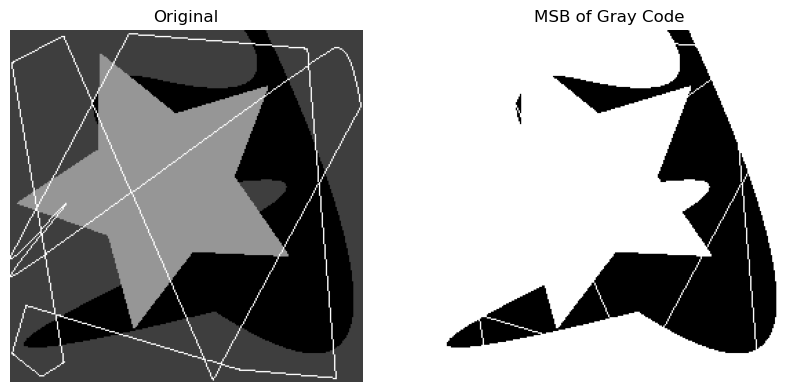

In [6]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Binary to Gray conversion: g = b ^ (b >> 1)
gray_img = img ^ (img >> 1)
bit_plane_gray = (gray_img >> 7) & 1
bit_plane_gray = (bit_plane_gray * 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(bit_plane_gray, cmap='gray'); plt.title('MSB of Gray Code'); plt.axis('off')
plt.show()

8.6 – Interpixel Redundancy Reduction (Difference Coding)

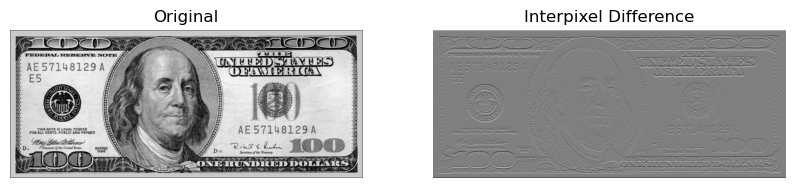

In [7]:
# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0314(a)(100-dollars).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.int16)

# Horizontal difference
diff_img = np.zeros_like(img)
diff_img[1:, :] = img[1:, :] - img[:-1, :]
res = cv2.normalize(diff_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(res, cmap='gray'); plt.title('Interpixel Difference'); plt.axis('off')
plt.show()

8.7 – Coding Redundancy Analysis (entropy / frequency count)

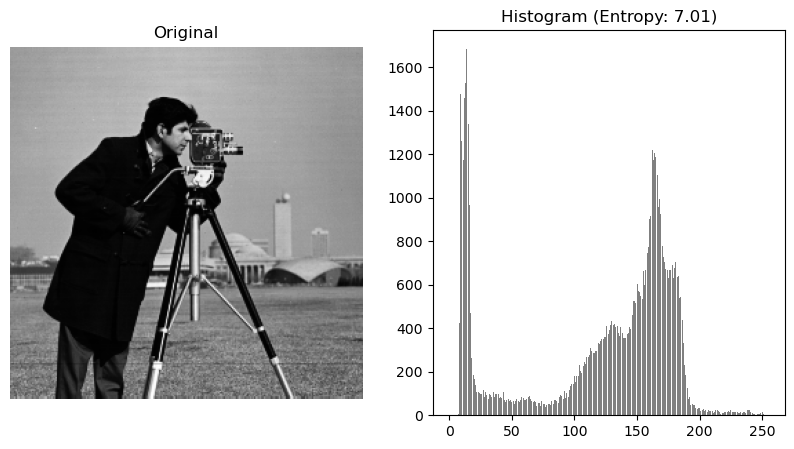

In [8]:
# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
probs = hist / img.size
probs = probs[probs > 0]
entropy = -np.sum(probs * np.log2(probs))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.bar(range(256), hist, color='gray'); plt.title(f'Histogram (Entropy: {entropy:.2f})')
plt.show()

8.8 – Improved Gray Scale (IGS) Quantization

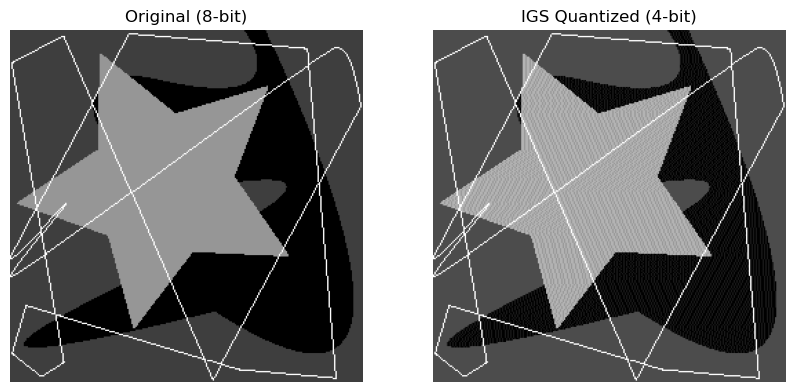

In [9]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def igs_quantization(image, bits=4):
    h, w = image.shape
    igs = np.zeros_like(image)
    sum_val = 0
    for i in range(h):
        for j in range(w):
            val = image[i, j]
            combined = val + (sum_val & 0x0F) if bits == 4 else val + (sum_val & 0x07)
            if combined > 255: combined = 255
            sum_val = combined
            igs[i, j] = (sum_val >> (8 - bits)) << (8 - bits)
    return igs

igs_img = igs_quantization(img, 4)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original (8-bit)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(igs_img, cmap='gray'); plt.title('IGS Quantized (4-bit)'); plt.axis('off')
plt.show()

8.9 – Source Encoder / Decoder Model Simulation

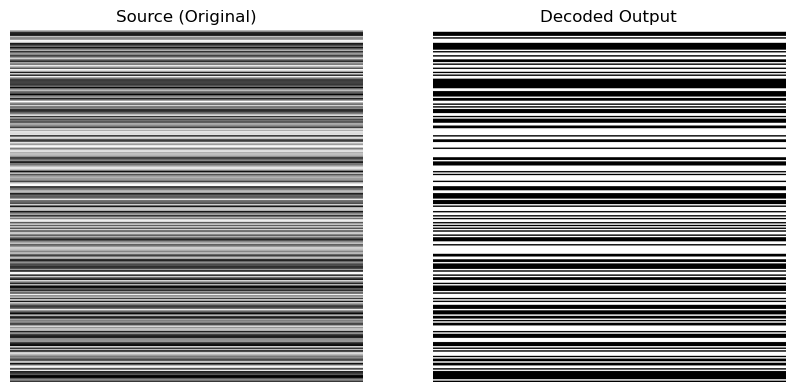

In [10]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(b).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Mapper (Thresholding as a simple source encoder)
encoded = (img > 128).astype(np.uint8) * 255
# Decoder (Direct representation)
decoded = encoded.copy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Source (Original)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(decoded, cmap='gray'); plt.title('Decoded Output'); plt.axis('off')
plt.show()

8.10 – Lossy Predictive Coding Model

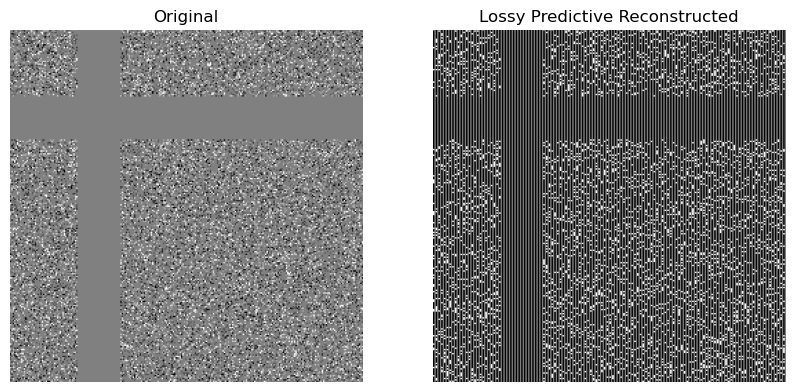

In [11]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(c).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

# Simple Delta Modulation (1-bit lossy predictive)
h, w = img.shape
reconstructed = np.zeros_like(img)
step = 20
prev = 128
for i in range(h):
    for j in range(w):
        error = img[i, j] - prev
        quantized_error = step if error > 0 else -step
        reconstructed[i, j] = np.clip(prev + quantized_error, 0, 255)
        prev = reconstructed[i, j]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(reconstructed.astype(np.uint8), cmap='gray'); plt.title('Lossy Predictive Reconstructed'); plt.axis('off')
plt.show()

8.11 – Compression Ratio & Relative Data Redundancy Calculation (C_R and R_D)

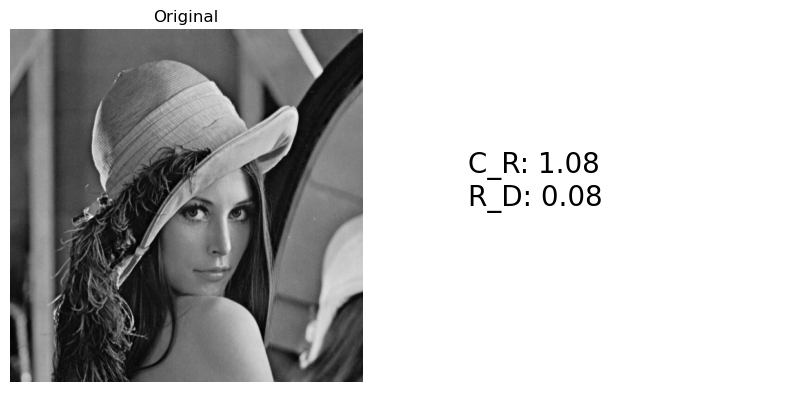

In [12]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0809(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

orig_size = img.size * 8 # bits
# Simulating a compressed size (e.g., using entropy)
hist = Counter(img.flatten())
probs = np.array(list(hist.values())) / img.size
entropy = -np.sum(probs * np.log2(probs))
comp_size = img.size * entropy

cr = orig_size / comp_size
rd = 1 - (1 / cr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.text(0.1, 0.5, f'C_R: {cr:.2f}\nR_D: {rd:.2f}', fontsize=20); plt.axis('off')
plt.show()

8.12 – Psychovisual Redundancy Demonstration (false contours vs IGS)

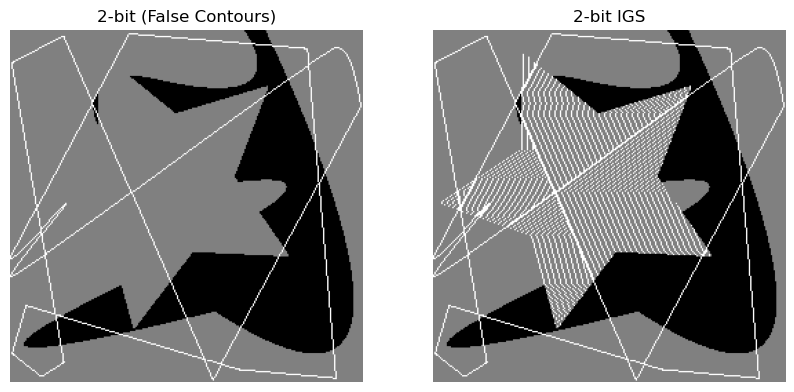

In [13]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Standard 2-bit quantization (False Contours)
false_contour = (img >> 6) << 6
# IGS 2-bit quantization
igs_2bit = igs_quantization(img, 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(false_contour, cmap='gray'); plt.title('2-bit (False Contours)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(igs_2bit, cmap='gray'); plt.title('2-bit IGS'); plt.axis('off')
plt.show()

8.13 – Run Length Coding on Binary Images (with 11-bit runs example)

[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.842] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

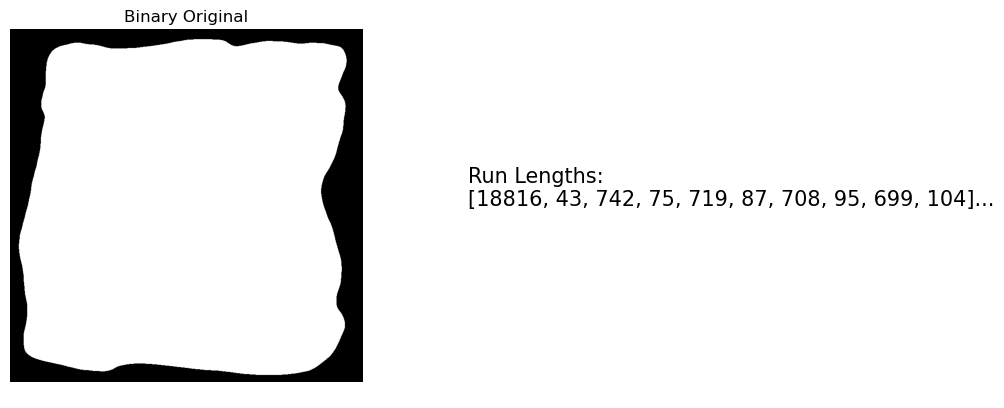

In [14]:
# Load the image
image_path = 'DIP3E_CH11_Original_Images/Fig1111(b)(square).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY)

def binary_rle(flat_data):
    runs = []
    curr = flat_data[0]
    count = 0
    for val in flat_data:
        if val == curr: count += 1
        else:
            runs.append(count)
            curr = val
            count = 1
    runs.append(count)
    return runs

runs = binary_rle(binary.flatten())
# Showing first few run lengths
vis_text = str(runs[:10]) + "..."

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Binary Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.text(0.1, 0.5, f'Run Lengths:\n{vis_text}', fontsize=15); plt.axis('off')
plt.show()

8.14 – Full Compression Pipeline Comparison

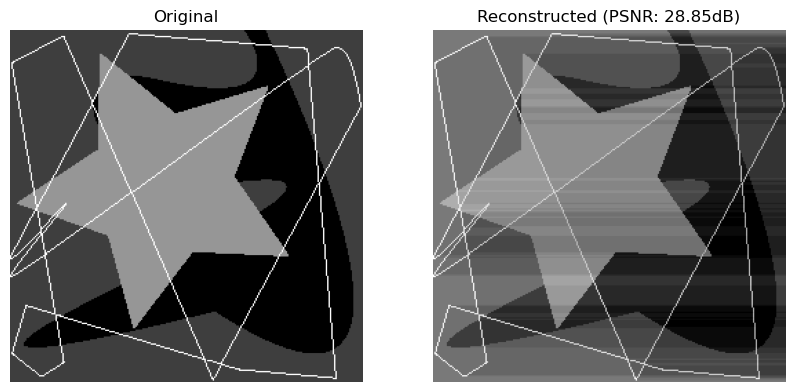

In [15]:
# Load the image
image_path = 'DIP3E_CH08_Original_Images/Fig0801(a).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Transform: Predictive
diff = np.zeros_like(img, dtype=np.int16)
diff[:, 1:] = img[:, 1:].astype(np.int16) - img[:, :-1].astype(np.int16)
diff[:, 0] = img[:, 0]

# 2. Quantize (Lossy)
quantized = (diff // 10) * 10

# 3. Reconstruct
recon = np.zeros_like(img, dtype=np.int16)
recon[:, 0] = quantized[:, 0]
for j in range(1, img.shape[1]):
    recon[:, j] = recon[:, j-1] + quantized[:, j]
recon = np.clip(recon, 0, 255).astype(np.uint8)

# PSNR Calculation
mse = np.mean((img - recon) ** 2)
psnr = 10 * np.log10((255**2) / mse) if mse > 0 else 100

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(recon, cmap='gray'); plt.title(f'Reconstructed (PSNR: {psnr:.2f}dB)'); plt.axis('off')
plt.show()